In [1]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import MACCSkeys

In [2]:
import random
import numpy as np
import pandas as pd
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, RocCurveDisplay, auc, roc_auc_score, matthews_corrcoef

In [4]:
import matplotlib.pyplot as plt

In [5]:
df1 = pd.read_csv('./ido1_tdo_fulljoin_20260205.csv', na_values=['na'])
#df1 = df1.dropna(ignore_index=True)
df1

,molecule_chembl_id,smiles,ido1_ic50,tdo_ic50
0,CHEMBL412131,Cc1c(SC[C@H](NC(=O)CC[C@H](N)C(=O)O)C(=O)NCC(=...,340.0,NaN
1,CHEMBL565489,Cc1cccc(N/C(=N\O)c2nonc2N)c1,550.0,NaN
2,CHEMBL107103,O=C(c1ccccc1)c1cccc(O)c1,500000.0,NaN
3,CHEMBL3342385,CCOC(=O)c1cnc2scc(C3=CCCCC3)n12,100000.0,NaN
4,CHEMBL3765545,O=C1CCc2cc(S(=O)(=O)NNc3ccc(Br)cc3)ccc2N1,72.7,NaN
...,...,...,...,...
4586,CHEMBL6053460,N#Cc1cc(-c2c[nH]c3cc(F)ccc23)ccc1S(=O)(=O)N1CC...,NaN,730.0
4587,CHEMBL5819188,NC(=O)CNc1ccc(-c2c[nH]c3cc(F)ccc23)cn1,NaN,790.0
4588,CHEMBL4849018,OCC(O)Cn1nnc2ccc(-c3c[nH]c4ccccc34)cc21,NaN,25200.0
4589,CHEMBL4176841,Cc1ccn(-c2cnoc2N)n1,NaN,1600.0


In [6]:
df2 = df1.loc[:, ['ido1_ic50', 'tdo_ic50']]
df2

,ido1_ic50,tdo_ic50
0,340.0,NaN
1,550.0,NaN
2,500000.0,NaN
3,100000.0,NaN
4,72.7,NaN
...,...,...
4586,NaN,730.0
4587,NaN,790.0
4588,NaN,25200.0
4589,NaN,1600.0


In [7]:
for i in range(len(df2)):
    if df2['ido1_ic50'].values[i] <= 1000:
        df2.loc[i, ['ido1_ic50']] = 1
    elif df2['ido1_ic50'].values[i] > 1000:
        df2.loc[i, ['ido1_ic50']] = 0
    else:
        df2.loc[i, ['ido1_ic50']] = np.nan

In [8]:
for i in range(len(df2)):
    if df2['tdo_ic50'].values[i] <= 1000:
        df2.loc[i, ['tdo_ic50']] = 1
    elif df2['tdo_ic50'].values[i] > 1000:
        df2.loc[i, ['tdo_ic50']] = 0
    else:
        df2.loc[i, ['tdo_ic50']] = np.nan

In [9]:
df2

,ido1_ic50,tdo_ic50
0,1.0,NaN
1,1.0,NaN
2,0.0,NaN
3,0.0,NaN
4,1.0,NaN
...,...,...
4586,NaN,1.0
4587,NaN,1.0
4588,NaN,0.0
4589,NaN,0.0


In [10]:
newcol = []
for i in range(len(df2)):
    if df2['ido1_ic50'].values[i] == 1.0 and df2['tdo_ic50'].values[i] == 1.0:
        newcol.append('AA')
    elif df2['ido1_ic50'].values[i] == 0.0 and df2['tdo_ic50'].values[i] == 0.0:
        newcol.append('II')
    elif df2['ido1_ic50'].values[i] == 0.0 and df2['tdo_ic50'].values[i] == 1.0:
        newcol.append('IA')
    elif df2['ido1_ic50'].values[i] == 1.0 and df2['tdo_ic50'].values[i] == 0.0:
        newcol.append('AI')
    else:
        newcol.append(np.nan)

In [11]:
len(newcol)

4591

In [12]:
target = pd.DataFrame(data=newcol, columns=['ido_tdo'])
target

,ido_tdo
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4586,NaN
4587,NaN
4588,NaN
4589,NaN


In [13]:
y = target.values.reshape(len(df2),)
y.shape

(4591,)

In [14]:
#Identify labeled nodes
# Boolean mask for labeled nodes
labeled_mask = target['ido_tdo'].notna()

# Get indices of labeled nodes
labeled_indices = target.index[labeled_mask].to_numpy()  # 1126 nodes


In [15]:
labeled_indices.shape

(1126,)

In [16]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_label = encoder.fit_transform(y[labeled_indices])

In [17]:
# Random & Stratify split
from sklearn.model_selection import train_test_split

def stratified_split_indices(labeled_indices, y_label, train_ratio=0.6, val_ratio=0.2, seed=42):
    """
    Stratified split of labeled_indices into train/val/test, stratified by y_label.
    Returns train_idx, val_idx, test_idx (subsets of labeled_indices).
    """
    labeled_indices = np.asarray(labeled_indices)
    y_label = np.asarray(y_label)

    test_ratio = 1.0 - train_ratio - val_ratio

    # First split: train vs (val+test)
    train_idx, temp_idx, train_y, temp_y = train_test_split(
        labeled_indices,
        y_label,
        train_size=train_ratio,
        stratify=y_label,
        random_state=seed
    )

    # Second split: val vs test (relative proportions within temp)
    val_size_relative = val_ratio / (val_ratio + test_ratio)
    val_idx, test_idx, val_y, test_y = train_test_split(
        temp_idx,
        temp_y,
        train_size=val_size_relative,
        stratify=temp_y,
        random_state=seed
    )

    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = stratified_split_indices(
    labeled_indices,
    y_label,
    train_ratio=0.6,
    val_ratio=0.2,
    seed=42
)

print("Train size:", len(train_idx))
print("Val size:", len(val_idx))
print("Test size:", len(test_idx))

Train size: 675
Val size: 225
Test size: 226


In [18]:
train_idx.shape

(675,)

In [19]:
#With random split:
len(train_idx), len(val_idx), len(test_idx)

(675, 225, 226)

In [20]:
#Create PyG masks
num_nodes = len(target)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True


In [21]:
from rdkit.Chem import SaltRemover as sr
remover = sr.SaltRemover()

In [22]:
mols = []
for i in range(len(df1)):
    try:
        mol_i = Chem.MolFromSmiles(df1['smiles'][i])
        if mol_i is None:
            print(f"[WARNING] Invalid SMILES at index {i}, skipping.")
            mols.append(None)  # Maintain indexing for multiprocessing
            continue
        mol_i = remover.StripMol(mol_i, dontRemoveEverything=True)
        mols.append(mol_i)
    except Exception as e:
        print(e)
len(mols)

4591

In [23]:
smiles_list = [df1['smiles'][i] for i in range(len(df1['smiles']))]

In [24]:
names_list = [df1['molecule_chembl_id'][i] for i in range(len(df1['molecule_chembl_id']))]

In [25]:
#MACCS Key as ExplicitBitVect
FPs = [MACCSkeys.GenMACCSKeys(mols[i]) for i in range(len(mols))]

In [26]:
#Generating MACCS key
l2 = np.zeros((1, 167))
for mol in mols:
    fp2 = MACCSkeys.GenMACCSKeys(mol)
    fp2 = fp2.ToList()
    fp2 = np.array(fp2)
    l2 = np.vstack((l2, fp2))
mfp = l2[1:, :]
mfp.shape

(4591, 167)

In [27]:
#Please notice to the type: it is ExplicitBitVect
type(FPs[0]), len(FPs[0]), len(FPs)

(rdkit.DataStructs.cDataStructs.ExplicitBitVect, 167, 4591)

In [28]:
similarity_matrix = np.zeros((len(FPs), len(FPs)))

In [29]:
similarity_matrix.shape

(4591, 4591)

In [30]:
#Calculate the diagonal elements
for i in range(len(FPs)):
    for j in range(i, len(FPs)):  # Avoid duplicate calculations
        similarity = DataStructs.TanimotoSimilarity(FPs[i], FPs[j])
        similarity_matrix[i, j] = similarity
        similarity_matrix[j, i] = similarity

In [31]:
similarity_matrix.shape

(4591, 4591)

In [32]:
import seaborn as sns

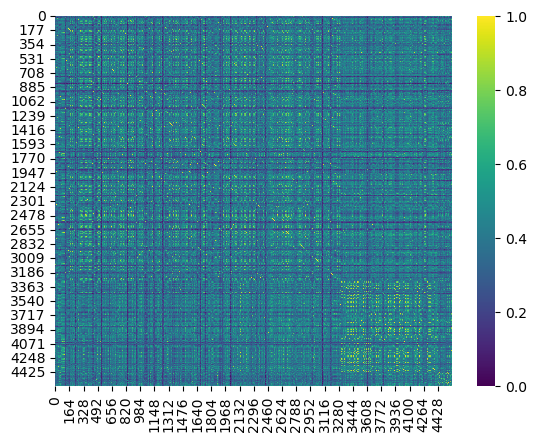

In [33]:
sns.heatmap(similarity_matrix, cmap='viridis');

In [34]:
similarity_matrix.min(), similarity_matrix.max(), similarity_matrix.mean()

(0.0, 1.0, 0.3952683912260438)

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7926152679e0>],
 'cmeans': <matplotlib.collections.LineCollection at 0x7926152a18e0>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x7926152a2120>,
 'cmins': <matplotlib.collections.LineCollection at 0x7926152a29c0>,
 'cbars': <matplotlib.collections.LineCollection at 0x792615433080>,
 'cmedians': <matplotlib.collections.LineCollection at 0x7926152a1490>}

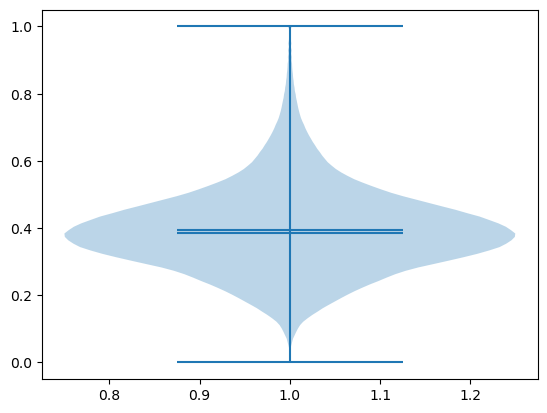

In [32]:
#MACCS key
plt.violinplot(similarity_matrix.flatten(), showmeans=True, showmedians=True)

In [35]:
import networkx as nx

In [36]:
#Build k-NN graph from similarity matrix
k = 15  # start with 10–20

In [37]:
#Mutual k-NN
#This avoids hubs:
max_w = np.max(similarity_matrix ** 2)
edges = set()
num_nodes = similarity_matrix.shape[0]
for i in range(num_nodes):
    sims = similarity_matrix[i]
    nn_idx = np.argsort(sims)[::-1][1:k+1]
    for j in nn_idx:
        edges.add((i, j))

G = nx.Graph()
for i, j in edges:
    if (j, i) in edges:
        w = (similarity_matrix[i, j]**2) / max_w
        G.add_edge(i, j, weight=w)

In [38]:
len(G.nodes), len(G.edges)

(4499, 21866)

In [39]:
G.number_of_nodes(), G.number_of_edges()

(4499, 21866)

In [40]:
#For MACCS
node_features = mfp

In [41]:
node_features.shape

(4591, 167)

In [42]:
#For PyG, node labels should be integers (0–3 for 4 classes).
# Map class names to integers
class_mapping = {'AA': 0, 'AI': 1, 'IA': 2, 'II': 3}
labels = target['ido_tdo'].map(class_mapping)

# Replace NaN with -1 (unlabeled)
labels = labels.fillna(-1).astype(int)

y = torch.tensor(labels.values, dtype=torch.long)

In [43]:
y

tensor([-1, -1, -1,  ..., -1, -1, -1])

In [44]:
#In the following steps, we are preparing and converting the data to a pytorch compatible input data.

In [45]:
#Step 2: Build edge list with weights from NetworkX

In [46]:
import torch
from torch_geometric.data import Data

# Assume G is your weighted NetworkX graph
edge_index = []
edge_attr = []

for u, v, data in G.edges(data=True):
    edge_index.append([u, v])
    edge_index.append([v, u])  # undirected graph → add both directions
    edge_attr.append([data['weight']])
    edge_attr.append([data['weight']])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()  # shape [2, num_edges]
edge_attr = torch.tensor(edge_attr, dtype=torch.float)                   # shape [num_edges, 1]

In [54]:
#Step 3: Add node features and labels

In [47]:
# Convert node features to tensor
x = torch.tensor(node_features, dtype=torch.float)  # shape [4591, 1024]

In [48]:
#Step 4: Create PyTorch Geometric Data object

In [49]:
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

print(data)
# Data(x=[760, 2048], edge_index=[2, num_edges], edge_attr=[num_edges, 1], y=[760])

Data(x=[4591, 167], edge_index=[2, 43732], edge_attr=[43732, 1], y=[4591])


In [50]:
data.edge_attr.shape

torch.Size([43732, 1])

In [51]:
# Attach to data object
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

In [52]:
data.train_mask.sum()

tensor(675)

In [53]:
# Assuming your Data object is already built with x, edge_index, edge_attr, y

print("Train nodes:", data.train_mask.sum().item())
print("Val nodes:", data.val_mask.sum().item())
print("Test nodes:", data.test_mask.sum().item())

Train nodes: 675
Val nodes: 225
Test nodes: 226


In [54]:
data.has_self_loops(), data.has_isolated_nodes()

(True, True)

In [55]:
data.num_classes = 4

In [56]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [57]:
#With skip connection and batchNorm added
import torch
import torch.nn.functional as F
import time
from torch.nn import Linear, Dropout
from torch_geometric.nn import GCNConv, BatchNorm

class GCN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_features, 64)
        self.bn1 = BatchNorm(64)
        self.conv2 = GCNConv(64, 32)
        self.bn2 = BatchNorm(32)
        self.conv3 = GCNConv(32, 16)
        # Skip connection linear projections
        self.skip1 = Linear(num_features, 64) if num_features != 64 else None
        self.skip2 = Linear(64, 32)
        self.skip3 = Linear(32, 16)
        self.classifier = Linear(16, num_classes)
        self.dropout = Dropout(p=0.5)

    def forward(self, x, edge_index, edge_weight=None):
        # Layer 1 with skip connection
        residual = x
        if self.skip1 is not None:
            residual = self.skip1(x)
        h = self.conv1(x, edge_index, edge_weight=edge_weight).relu()
        h = self.bn1(h)
        h = h + residual  # Skip connection
        h = self.dropout(h)
        
        # Layer 2 with skip connection
        residual = h
        residual = self.skip2(residual)
        h = self.conv2(h, edge_index, edge_weight=edge_weight).relu()
        h = self.bn2(h)
        h = h + residual  # Skip connection
        h = self.dropout(h)
        
        # Layer 3 with skip connection
        residual = h
        residual = self.skip3(residual)
        h = self.conv3(h, edge_index, edge_weight=edge_weight)
        h = h + residual  # Skip connection
        
        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h  # LogSoftmax for NLLLoss

In [58]:
# Transductive GCN

data = data.to(device)
model = GCN(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
#model = model.to(data.x.device)  # Ensure device consistency
criterion = torch.nn.NLLLoss()  # Changed for log_softmax output
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, edge_weight=data.edge_attr.squeeze())
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
    optimizer.step()

    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, edge_weight=data.edge_attr.squeeze())  # Consistent edge_weight
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(200):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    # Early stopping and checkpointing
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_gcn_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")
        

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model for final test - SECURE
checkpoint = torch.load('best_gcn_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


Train/Val/Test nodes: 675/225/226
Epoch 000 | Train Loss: 1.9347 | Train Acc: 0.2207 | Val Loss: 1.3744 | Val Acc: 0.1867 | Best: 0.1867
Epoch 010 | Train Loss: 1.0159 | Train Acc: 0.5881 | Val Loss: 1.1395 | Val Acc: 0.4578 | Best: 0.4667
Epoch 020 | Train Loss: 0.8363 | Train Acc: 0.6933 | Val Loss: 0.9362 | Val Acc: 0.5956 | Best: 0.6000
Epoch 030 | Train Loss: 0.7365 | Train Acc: 0.6919 | Val Loss: 0.8302 | Val Acc: 0.6267 | Best: 0.6267
Epoch 040 | Train Loss: 0.6786 | Train Acc: 0.7111 | Val Loss: 0.7814 | Val Acc: 0.6756 | Best: 0.6800
Epoch 050 | Train Loss: 0.6461 | Train Acc: 0.7230 | Val Loss: 0.7525 | Val Acc: 0.6933 | Best: 0.6933
Epoch 060 | Train Loss: 0.6089 | Train Acc: 0.7289 | Val Loss: 0.7393 | Val Acc: 0.7111 | Best: 0.7111
Epoch 070 | Train Loss: 0.5894 | Train Acc: 0.7319 | Val Loss: 0.7393 | Val Acc: 0.7022 | Best: 0.7156
Epoch 080 | Train Loss: 0.5742 | Train Acc: 0.7378 | Val Loss: 0.7558 | Val Acc: 0.7200 | Best: 0.7200
Epoch 090 | Train Loss: 0.5476 | Train 

In [59]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.703     0.907     0.792        86
           1      0.808     0.618     0.700        68
           2      0.400     0.200     0.267        10
           3      0.776     0.726     0.750        62

    accuracy                          0.739       226
   macro avg      0.672     0.613     0.627       226
weighted avg      0.741     0.739     0.730       226



In [60]:
out_test.shape

torch.Size([4591, 4])

In [61]:
import torch.nn.functional as F

In [62]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [63]:
y_true.shape

torch.Size([226])

In [64]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.8685330350739493

In [65]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average=None)

array([0.87093023, 0.87178891, 0.85046296, 0.88095004])

In [66]:
matthews_corrcoef(y_true, y_pred)

0.6205253908109889

In [68]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, BatchNorm

class GIN(nn.Module):
    def __init__(self, num_features, num_classes, hidden_dims=(64, 32, 16), dropout=0.4):
        super().__init__()

        def mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Linear(out_dim, out_dim),
            )

        # -------- GIN layers --------
        self.conv1 = GINConv(mlp(num_features, hidden_dims[0]), train_eps=True)
        self.bn1 = BatchNorm(hidden_dims[0])

        self.conv2 = GINConv(mlp(hidden_dims[0], hidden_dims[1]), train_eps=True)
        self.bn2 = BatchNorm(hidden_dims[1])

        self.conv3 = GINConv(mlp(hidden_dims[1], hidden_dims[2]), train_eps=True)

        # -------- Skip connections --------
        self.skip1 = nn.Linear(num_features, hidden_dims[0]) if num_features != hidden_dims[0] else None
        self.skip2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.skip3 = nn.Linear(hidden_dims[1], hidden_dims[2])

        self.classifier = nn.Linear(hidden_dims[2], num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        # ---- Layer 1 ----
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index)
        h = self.dropout(h)
        h = h + residual
        h = self.bn1(h)
        h = F.relu(h)

        # ---- Layer 2 ----
        residual = self.skip2(h)
        h = self.conv2(h, edge_index)
        h = self.dropout(h)
        h = h + residual
        h = self.bn2(h)
        h = F.relu(h)

        # ---- Layer 3 ----
        residual = self.skip3(h)
        h = self.conv3(h, edge_index)
        h = h + residual

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [69]:
#Transductive GIN

data = data.to(device)
model = GIN(num_features=data.num_features, num_classes=data.num_classes).to(device)
criterion = torch.nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

def evaluate(data, mask):
    model.eval()
    with torch.no_grad():
        out, h = model(data.x, data.edge_index)  # full-graph forward
        loss = criterion(out[mask], data.y[mask])
        pred = out[mask].argmax(dim=1)
        acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

num_epochs = 200
for epoch in range(1, num_epochs + 1):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | "
              f"Train Acc: {acc_train:.4f} | Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f}")

# Final test evaluation
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")

Epoch 010 | Train Loss: 0.9935 | Train Acc: 0.6193 | Val Loss: 1.0244 | Val Acc: 0.5822
Epoch 020 | Train Loss: 0.8543 | Train Acc: 0.6667 | Val Loss: 0.9254 | Val Acc: 0.6356
Epoch 030 | Train Loss: 0.7833 | Train Acc: 0.6741 | Val Loss: 0.8936 | Val Acc: 0.6356
Epoch 040 | Train Loss: 0.7313 | Train Acc: 0.6859 | Val Loss: 0.8465 | Val Acc: 0.6667
Epoch 050 | Train Loss: 0.6586 | Train Acc: 0.7185 | Val Loss: 0.8189 | Val Acc: 0.6844
Epoch 060 | Train Loss: 0.6320 | Train Acc: 0.7274 | Val Loss: 0.8027 | Val Acc: 0.6844
Epoch 070 | Train Loss: 0.6088 | Train Acc: 0.7319 | Val Loss: 0.7587 | Val Acc: 0.6933
Epoch 080 | Train Loss: 0.5688 | Train Acc: 0.7496 | Val Loss: 0.7968 | Val Acc: 0.6978
Epoch 090 | Train Loss: 0.5491 | Train Acc: 0.7481 | Val Loss: 0.8402 | Val Acc: 0.6933
Epoch 100 | Train Loss: 0.5175 | Train Acc: 0.7793 | Val Loss: 0.8869 | Val Acc: 0.6933
Epoch 110 | Train Loss: 0.5072 | Train Acc: 0.7600 | Val Loss: 0.8368 | Val Acc: 0.6756
Epoch 120 | Train Loss: 0.4791 |

In [70]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.747     0.721     0.734        86
           1      0.662     0.721     0.690        68
           2      0.500     0.200     0.286        10
           3      0.723     0.758     0.740        62

    accuracy                          0.708       226
   macro avg      0.658     0.600     0.612       226
weighted avg      0.704     0.708     0.703       226



In [71]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [72]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.8721007161986563

In [73]:
matthews_corrcoef(y_true, y_pred)

0.5725862417423531

In [74]:
#GINEConv with skip connection
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, BatchNorm

class GINE(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_dims=(64, 32, 16), dropout=0.4):
        super().__init__()

        def node_mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Linear(out_dim, out_dim),
            )

        # -------- GINE layers --------
        self.conv1 = GINEConv(
            node_mlp(num_features, hidden_dims[0]),
            edge_dim=1,
            train_eps=True
        )
        self.bn1 = BatchNorm(hidden_dims[0])

        self.conv2 = GINEConv(
            node_mlp(hidden_dims[0], hidden_dims[1]),
            edge_dim=1,
            train_eps=True
        )
        self.bn2 = BatchNorm(hidden_dims[1])

        self.conv3 = GINEConv(
            node_mlp(hidden_dims[1], hidden_dims[2]),
            edge_dim=1,
            train_eps=True
        )

        # -------- Skip connections --------
        self.skip1 = nn.Linear(num_features, hidden_dims[0]) if num_features != hidden_dims[0] else None
        self.skip2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.skip3 = nn.Linear(hidden_dims[1], hidden_dims[2])

        self.classifier = nn.Linear(hidden_dims[2], num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_attr):
        # Ensure correct edge shape
        edge_attr = edge_attr.view(-1, 1)

        # ---- Layer 1 ----
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index, edge_attr)
        h = self.dropout(h)
        h = h + residual
        h = self.bn1(h)
        h = F.relu(h)

        # ---- Layer 2 ----
        residual = self.skip2(h)
        h = self.conv2(h, edge_index, edge_attr)
        h = self.dropout(h)
        h = h + residual
        h = self.bn2(h)
        h = F.relu(h)

        # ---- Layer 3 (no activation) ----
        residual = self.skip3(h)
        h = self.conv3(h, edge_index, edge_attr)
        h = h + residual

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [75]:
# Transductive GINE

#device = data.x.device
data = data.to(device)
model = GINE(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
criterion = torch.nn.NLLLoss()  # Changed for log_softmax
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)  # Added L2

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Re-enabled gradient clipping
    optimizer.step()
    
    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Enhanced training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("GINE | Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(1, 201):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    # Early stopping + checkpointing
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_gine_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model securely and test
checkpoint = torch.load('best_gine_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"GINE Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


GINE | Train/Val/Test nodes: 675/225/226
Epoch 010 | Train Loss: 0.9553 | Train Acc: 0.6015 | Val Loss: 1.1122 | Val Acc: 0.4844 | Best: 0.4844
Epoch 020 | Train Loss: 0.7885 | Train Acc: 0.6637 | Val Loss: 0.9052 | Val Acc: 0.5378 | Best: 0.6044
Epoch 030 | Train Loss: 0.7002 | Train Acc: 0.6978 | Val Loss: 1.0927 | Val Acc: 0.5733 | Best: 0.6044
Epoch 040 | Train Loss: 0.6830 | Train Acc: 0.6993 | Val Loss: 1.1233 | Val Acc: 0.5911 | Best: 0.6533
Epoch 050 | Train Loss: 0.6320 | Train Acc: 0.6933 | Val Loss: 0.8133 | Val Acc: 0.6578 | Best: 0.6889
Epoch 060 | Train Loss: 0.5499 | Train Acc: 0.7556 | Val Loss: 0.8398 | Val Acc: 0.6222 | Best: 0.6889
Epoch 070 | Train Loss: 0.5213 | Train Acc: 0.7704 | Val Loss: 0.9472 | Val Acc: 0.6667 | Best: 0.6889
Epoch 080 | Train Loss: 0.4556 | Train Acc: 0.7837 | Val Loss: 0.9320 | Val Acc: 0.6089 | Best: 0.6889
Epoch 090 | Train Loss: 0.4309 | Train Acc: 0.8015 | Val Loss: 0.9544 | Val Acc: 0.6178 | Best: 0.6889
Early stopping at epoch 97
GINE 

In [76]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.639     0.884     0.741        86
           1      0.773     0.500     0.607        68
           2      0.000     0.000     0.000        10
           3      0.762     0.774     0.768        62

    accuracy                          0.699       226
   macro avg      0.543     0.539     0.529       226
weighted avg      0.685     0.699     0.676       226



/home/linu/anaconda3/envs/embedding/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/linu/anaconda3/envs/embedding/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/linu/anaconda3/envs/embedding/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

In [77]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [78]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.8844098333166548

In [79]:
matthews_corrcoef(y_true, y_pred)

0.5629548115200903

In [80]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, BatchNorm

class GAT_EdgeWeighted(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_dims=(64, 32, 16), dropout=0.4):
        super().__init__()

        # -------- GAT layers (edge-aware) --------
        self.conv1 = GATConv(
            in_channels=num_features,
            out_channels=hidden_dims[0] // 4,
            heads=4,
            concat=True,
            dropout=dropout,
            add_self_loops=True,
            edge_dim=1,          # <-- edge weights used
        )
        self.bn1 = BatchNorm(hidden_dims[0])

        self.conv2 = GATConv(
            in_channels=hidden_dims[0],
            out_channels=hidden_dims[1] // 2,
            heads=2,
            concat=True,
            dropout=dropout,
            add_self_loops=True,
            edge_dim=1,
        )
        self.bn2 = BatchNorm(hidden_dims[1])

        self.conv3 = GATConv(
            in_channels=hidden_dims[1],
            out_channels=hidden_dims[2],
            heads=1,
            concat=False,
            dropout=dropout,
            add_self_loops=True,
            edge_dim=1,
        )

        # -------- Skip connections --------
        self.skip1 = nn.Linear(num_features, hidden_dims[0]) if num_features != hidden_dims[0] else None
        self.skip2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.skip3 = nn.Linear(hidden_dims[1], hidden_dims[2])

        self.classifier = nn.Linear(hidden_dims[2], num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_weight):
        # Ensure edge_weight has shape [E, 1]
        if edge_weight is not None:
            edge_weight = edge_weight.view(-1, 1)

        # ---- Layer 1 ----
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index, edge_weight)
        h = h + residual
        h = self.bn1(h)
        h = F.elu(h)
        h = self.dropout(h)

        # ---- Layer 2 ----
        residual = self.skip2(h)
        h = self.conv2(h, edge_index, edge_weight)
        h = h + residual
        h = self.bn2(h)
        h = F.elu(h)
        h = self.dropout(h)

        # ---- Layer 3 (no activation) ----
        residual = self.skip3(h)
        h = self.conv3(h, edge_index, edge_weight)
        h = h + residual

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [81]:
#Transductive GAT learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
from torch_geometric.nn import GATConv, BatchNorm


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data = data.to(device)
model = GAT_EdgeWeighted(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-3)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, data.edge_attr)  # edge_attr passed but ignored
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    
    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, data.edge_attr)  # edge_attr ignored
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("GAT | Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(1, 201):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_gat_transductive_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model securely
checkpoint = torch.load('best_gat_transductive_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"GAT Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


GAT | Train/Val/Test nodes: 675/225/226
Epoch 010 | Train Loss: 0.8146 | Train Acc: 0.6504 | Val Loss: 0.9916 | Val Acc: 0.5511 | Best: 0.5511
Epoch 020 | Train Loss: 0.6781 | Train Acc: 0.7111 | Val Loss: 0.8635 | Val Acc: 0.5956 | Best: 0.6311
Epoch 030 | Train Loss: 0.6141 | Train Acc: 0.7244 | Val Loss: 0.7527 | Val Acc: 0.6889 | Best: 0.7022
Epoch 040 | Train Loss: 0.6077 | Train Acc: 0.7319 | Val Loss: 0.7888 | Val Acc: 0.6756 | Best: 0.7022
Epoch 050 | Train Loss: 0.5491 | Train Acc: 0.7674 | Val Loss: 0.7293 | Val Acc: 0.7156 | Best: 0.7289
Epoch 060 | Train Loss: 0.5292 | Train Acc: 0.7659 | Val Loss: 0.7751 | Val Acc: 0.7244 | Best: 0.7378
Epoch 070 | Train Loss: 0.5200 | Train Acc: 0.7807 | Val Loss: 0.8198 | Val Acc: 0.7111 | Best: 0.7556
Epoch 080 | Train Loss: 0.4906 | Train Acc: 0.7896 | Val Loss: 0.7788 | Val Acc: 0.6978 | Best: 0.7556
Epoch 090 | Train Loss: 0.4636 | Train Acc: 0.7985 | Val Loss: 0.8016 | Val Acc: 0.7333 | Best: 0.7556
Epoch 100 | Train Loss: 0.4446 | 

In [82]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.783     0.756     0.769        86
           1      0.699     0.750     0.723        68
           2      0.000     0.000     0.000        10
           3      0.725     0.806     0.763        62

    accuracy                          0.735       226
   macro avg      0.552     0.578     0.564       226
weighted avg      0.707     0.735     0.720       226



In [83]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [84]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.8736538995842504

In [85]:
matthews_corrcoef(y_true, y_pred)

0.6105732527712249

In [86]:
import torch
from torch import nn
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import scatter

In [87]:
#SAGEConv layer of PyG does NOT accept edge_weight. So, we have to implement it manually.
#You are using weighted sum aggregation in the below architecture: Sum aggregation Weighted by edge weights.

In [88]:
class WeightedSAGEConv(MessagePassing):
    def __init__(self, in_channels, out_channels, bias=True):
        super().__init__(aggr='add')  # aggregation method: weighted sum
        self.lin = nn.Linear(in_channels, out_channels, bias=bias)

    def forward(self, x, edge_index, edge_weight):
        # x: [N, F]
        # edge_index: [2, E]
        # edge_weight: [E]
        return self.propagate(edge_index, x=x, edge_weight=edge_weight)

    def message(self, x_j, edge_weight):
        # x_j: neighbor features
        return edge_weight.view(-1, 1) * x_j

    def update(self, aggr_out):
        # Linear transformation after aggregation
        return self.lin(aggr_out)

In [89]:
#PyG’s SAGEConv uses mean by default
#If you want to use weighted-mean GraphSAGE aggregation:

In [90]:
from torch_geometric.utils import scatter

class WeightedMeanSAGEConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, edge_weight=None):
        if edge_weight is None:
            edge_weight = x.new_ones(edge_index.size(1))

        self.edge_weight = edge_weight
        return self.propagate(edge_index, x=x)

    def message(self, x_j):
        return x_j * self.edge_weight.view(-1, 1)

    def aggregate(self, inputs, index):
        weighted_sum = scatter(inputs, index, dim=0, reduce='sum')
        weight_sum = scatter(
            self.edge_weight, index, dim=0, reduce='sum'
        ).view(-1, 1)

        return weighted_sum / (weight_sum + 1e-8)

    def update(self, aggr_out):
        return self.lin(aggr_out)


In [91]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, Dropout
from torch_geometric.nn import BatchNorm

class GraphSAGE(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()

        self.conv1 = WeightedMeanSAGEConv(num_features, 64)
        self.bn1 = BatchNorm(64)

        self.conv2 = WeightedMeanSAGEConv(64, 32)
        self.bn2 = BatchNorm(32)

        self.conv3 = WeightedMeanSAGEConv(32, 16)

        # Skip connections
        self.skip1 = Linear(num_features, 64) if num_features != 64 else None
        self.skip2 = Linear(64, 32)
        self.skip3 = Linear(32, 16)

        self.classifier = Linear(16, num_classes)
        self.dropout = Dropout(p=0.4)

    def forward(self, x, edge_index, edge_weight):
        # ---- Layer 1 ----
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index, edge_weight)
        h = F.relu(h)
        h = self.bn1(h)
        h = h + residual
        h = self.dropout(h)

        # ---- Layer 2 ----
        residual = self.skip2(h)
        h = self.conv2(h, edge_index, edge_weight)
        h = F.relu(h)
        h = self.bn2(h)
        h = h + residual
        h = self.dropout(h)

        # ---- Layer 3 ----
        residual = self.skip3(h)
        h = self.conv3(h, edge_index, edge_weight)
        h = h + residual

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [92]:
# Transductive GraphSAGE

data = data.to(device)
model = GraphSAGE(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
criterion = torch.nn.NLLLoss()  # Changed for log_softmax
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)  # Added L2
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Re-enabled gradient clipping
    optimizer.step()
    scheduler.step()
    
    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Enhanced training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("GraphSAGE | Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(1, 201):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    # Early stopping + checkpointing
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_graphSAGE_transductive_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model securely and test
checkpoint = torch.load('best_graphSAGE_transductive_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"GraphSAGE Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


GraphSAGE | Train/Val/Test nodes: 675/225/226
Epoch 010 | Train Loss: 0.7088 | Train Acc: 0.6741 | Val Loss: 1.1862 | Val Acc: 0.4489 | Best: 0.4489
Epoch 020 | Train Loss: 0.6078 | Train Acc: 0.7378 | Val Loss: 0.9137 | Val Acc: 0.6222 | Best: 0.6533
Epoch 030 | Train Loss: 0.5328 | Train Acc: 0.7600 | Val Loss: 0.8565 | Val Acc: 0.6533 | Best: 0.6756
Epoch 040 | Train Loss: 0.5014 | Train Acc: 0.7778 | Val Loss: 0.8581 | Val Acc: 0.7156 | Best: 0.7156
Epoch 050 | Train Loss: 0.4703 | Train Acc: 0.7837 | Val Loss: 0.8854 | Val Acc: 0.7244 | Best: 0.7244
Epoch 060 | Train Loss: 0.4568 | Train Acc: 0.7970 | Val Loss: 0.9663 | Val Acc: 0.6978 | Best: 0.7244
Epoch 070 | Train Loss: 0.4294 | Train Acc: 0.7956 | Val Loss: 1.0841 | Val Acc: 0.6978 | Best: 0.7333
Epoch 080 | Train Loss: 0.4184 | Train Acc: 0.8267 | Val Loss: 1.0714 | Val Acc: 0.7022 | Best: 0.7333
Epoch 090 | Train Loss: 0.4226 | Train Acc: 0.8163 | Val Loss: 1.0875 | Val Acc: 0.7244 | Best: 0.7333
Epoch 100 | Train Loss: 0.3

In [93]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.679     0.860     0.759        86
           1      0.721     0.647     0.682        68
           2      0.500     0.100     0.167        10
           3      0.796     0.694     0.741        62

    accuracy                          0.717       226
   macro avg      0.674     0.575     0.587       226
weighted avg      0.716     0.717     0.705       226



In [94]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [95]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.8271562583381822

In [96]:
matthews_corrcoef(y_true, y_pred)

0.5833389706736088